# Step 3 Diagnostic: Does the Pitch Encoder Track Real Pitch?

Per the README: this notebook "sanity-checks the trained pitch encoder's
output against a standard pitch-detection formula, purely as a diagnostic
— never used as a training signal." It is diagnostic-only: no training, no
checkpoint modification, and — per the project's core design principle —
no emotion labels anywhere in this notebook.

Training results being investigated here (from `train_pitch_encoder.py`):

Train pairs: 7200 | Val pairs (held-out actors 21,22,23,24): 1440
Epoch 1/20 | train_loss=3.461485 | val_loss=3.303762
Epoch 20/20 | train_loss=2.981131 | val_loss=2.954908 (best, saved to best.pt)


MSE ≈ 2.95 against ±1/±2/±3-semitone targets implies a typical error around
√2.95 ≈ 1.7 semitones. Loss trended down but stayed noisy and didn't
clearly converge. This notebook checks, empirically, whether the encoder
learned a real, usable pitch signal despite that — by correlating its
output against `librosa.pyin()` (an established, non-neural pitch
estimator) on held-out clips, not by restating the loss number.

**Note on running this notebook:** the imports below use absolute
`from src...` paths, which assumes the Jupyter kernel's working directory
is the project root (`SentiSpeak/`), the same way the `.py` scripts assume
`python -m src...` is run from the root. If the import cell fails with
`ModuleNotFoundError: No module named 'src'`, the kernel's cwd is probably
`notebooks/` instead — either start Jupyter from the project root, or add
a cell above the imports with `import sys; sys.path.insert(0, "..")`.

In [1]:
import os
import sys

# Make the notebook behave as if launched from the project root, matching
# how the .py scripts assume `python -m src...` is run from the root.
os.chdir("..")
sys.path.insert(0, ".")

print(f"Working directory is now: {os.getcwd()}")

Working directory is now: C:\Users\SAYAN DATTA\Desktop\Project List\SentiSpeak


In [2]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from src.models.pitch_encoder import PitchEncoder
from src.training.train_pitch_encoder import HELD_OUT_ACTORS
from src.utils.audio_utils import get_pitch_pair_mels, slice_frame
from src.utils.config import (
    HOP_LENGTH,
    N_FFT,
    N_MELS,
    PITCH_ENCODER_CHECKPOINT_DIR,
    PITCH_PAIRS_METADATA_CSV,
    SAMPLE_RATE,
)

# Using pandas' built-in .corr() later instead of scipy.stats — you've got
# scipy transitively via scikit-learn, but this avoids depending on it
# directly. Swap in scipy.stats.pearsonr/spearmanr if you also want p-values.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Same constructor args train_pitch_encoder.py used (its own defaults):
# n_mels=128, window_size=1, output_dim=1.
model = PitchEncoder(n_mels=N_MELS, window_size=1, output_dim=1)

checkpoint_path = PITCH_ENCODER_CHECKPOINT_DIR / "best.pt"
# weights_only=True: this checkpoint is just a state_dict (plain tensors),
# so this is safe and is the currently-recommended torch.load pattern.
state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.to(device)
model.eval()  # inference only — no training happens anywhere in this notebook

print(f"Loaded weights from {checkpoint_path}")

Using device: cuda
Loaded weights from checkpoints\pitch_encoder\best.pt


In [4]:
# DESIGN CHOICE (flagging, since this wasn't specified): sampling only from
# the held-out validation actors (21-24), not the full pitch_pairs_metadata.csv.
# The encoder never saw these actors' pairs during training (train_pitch_encoder.py's
# actor-based split), so this is the honest way to check whether it generalizes,
# rather than partly measuring memorization of training clips.
pitch_pairs = pd.read_csv(PITCH_PAIRS_METADATA_CSV)
val_pairs = pitch_pairs[pitch_pairs["actor"].isin(HELD_OUT_ACTORS)]

sample = val_pairs.sample(n=30, random_state=42).reset_index(drop=True)
print(f"Sampled {len(sample)} pairs from held-out actors {HELD_OUT_ACTORS}")
sample.head()

Sampled 30 pairs from held-out actors (21, 22, 23, 24)


,original_path,shifted_path,shift_semitones,sr,actor,gender,emotion,intensity,statement,repetition
0,data\raw\Audio_Speech_Actors_01-24\Actor_21\03...,data\processed\pitch_shifted\Actor_21\03-01-05...,-3.0,48000,21,male,angry,normal,kids_are_talking_by_the_door,1
1,data\raw\Audio_Speech_Actors_01-24\Actor_22\03...,data\processed\pitch_shifted\Actor_22\03-01-06...,3.0,48000,22,female,fearful,strong,kids_are_talking_by_the_door,1
2,data\raw\Audio_Speech_Actors_01-24\Actor_22\03...,data\processed\pitch_shifted\Actor_22\03-01-05...,-1.0,48000,22,female,angry,normal,dogs_are_sitting_by_the_door,2
3,data\raw\Audio_Speech_Actors_01-24\Actor_21\03...,data\processed\pitch_shifted\Actor_21\03-01-02...,3.0,48000,21,male,calm,strong,dogs_are_sitting_by_the_door,1
4,data\raw\Audio_Speech_Actors_01-24\Actor_22\03...,data\processed\pitch_shifted\Actor_22\03-01-07...,2.0,48000,22,female,disgust,normal,kids_are_talking_by_the_door,1


In [5]:
def estimate_pitch_hz(wav_path: str) -> np.ndarray:
    """Per-frame f0 estimate in Hz (NaN where pyin judges the frame unvoiced)."""
    y, loaded_sr = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True)
    f0, voiced_flag, voiced_probs = librosa.pyin(
        y,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7"),
        sr=loaded_sr,
        frame_length=N_FFT,      # matches extract_mel.py's n_fft (1024)
        hop_length=HOP_LENGTH,   # matches extract_mel.py's hop_length (256),
                                  # so pyin's frame index i lines up with the
                                  # mel-spectrogram's frame index i (approximately
                                  # — see closing note on this assumption)
    )
    return f0

pitch_records = []  # one entry per (pair, role) — role is "original" or "shifted"

for i, row in sample.iterrows():
    for role, wav_path in [("original", row["original_path"]), ("shifted", row["shifted_path"])]:
        f0_hz = estimate_pitch_hz(wav_path)
        pitch_records.append({"pair_idx": i, "role": role, "f0_hz": f0_hz})

print(f"Computed pyin pitch tracks for {len(pitch_records)} clips (2 per sampled pair).")
# Note: pyin is noticeably slower than a simple pitch estimator — this cell
# may take a minute or two for 60 clips.

Computed pyin pitch tracks for 60 clips (2 per sampled pair).


In [6]:
encoder_records = []  # aligned 1:1 with pitch_records

with torch.no_grad():
    for i, row in sample.iterrows():
        # Reusing get_pitch_pair_mels() here is fine — this is a one-off
        # diagnostic loop over 30 pairs, not a training loop called thousands
        # of times, so its "re-reads the manifest CSV every call" perf note
        # (flagged in audio_utils.py) doesn't apply here.
        original_mel, shifted_mel, shift_semitones = get_pitch_pair_mels(row)

        for role, mel in [("original", original_mel), ("shifted", shifted_mel)]:
            n_frames = mel.shape[1]
            outputs = []
            for frame_idx in range(n_frames):
                frame = slice_frame(mel, frame_idx, window_size=1)      # (n_mels, 1)
                frame_batched = frame.unsqueeze(0).to(device)           # (1, n_mels, 1)
                out = model(frame_batched)                              # (1, 1)
                outputs.append(out.item())
            encoder_records.append({"pair_idx": i, "role": role, "encoder_outputs": outputs})

print(f"Computed encoder outputs for {len(encoder_records)} clips.")

Computed encoder outputs for 60 clips.


In [7]:
rows = []
for pitch_rec, enc_rec in zip(pitch_records, encoder_records):
    assert pitch_rec["pair_idx"] == enc_rec["pair_idx"] and pitch_rec["role"] == enc_rec["role"]
    f0 = pitch_rec["f0_hz"]
    enc_out = enc_rec["encoder_outputs"]
    n = min(len(f0), len(enc_out))  # pyin/mel frame counts can differ by 1-2 at clip edges
    for frame_idx in range(n):
        f0_val = f0[frame_idx]
        if np.isnan(f0_val):
            continue  # unvoiced frame — no ground-truth pitch to compare against
        rows.append({
            "pair_idx": pitch_rec["pair_idx"],
            "role": pitch_rec["role"],
            "frame_idx": frame_idx,
            "f0_hz": f0_val,
            "encoder_output": enc_out[frame_idx],
        })

comparison_df = pd.DataFrame(rows)
print(f"{len(comparison_df)} voiced frames available for correlation.")

# Hz -> semitone-relative scale (flagging this conversion explicitly, as
# asked): the encoder's output isn't in Hz — it's an arbitrary learned
# scale, only ever trained so that DIFFERENCES track semitone shifts.
# Converting ground truth to semitones (relative to an arbitrary reference,
# C2) at least puts it on a scale where equal steps mean equal perceived
# pitch change — closer in spirit to what the encoder was actually trained
# against. It does NOT make the two scales numerically comparable (the
# encoder could still have an arbitrary linear transform relative to this),
# which matters more for Pearson than Spearman (rank-only).
comparison_df["f0_semitones"] = 12 * np.log2(comparison_df["f0_hz"] / librosa.note_to_hz("C2"))

pearson_r = comparison_df["encoder_output"].corr(comparison_df["f0_semitones"], method="pearson")
spearman_r = comparison_df["encoder_output"].corr(comparison_df["f0_semitones"], method="spearman")

print(f"Pooled Pearson r  = {pearson_r:.4f}")
print(f"Pooled Spearman r = {spearman_r:.4f}")

7936 voiced frames available for correlation.
Pooled Pearson r  = 0.6652
Pooled Spearman r = 0.7887


Per-clip Pearson r: median=0.302, mean=0.274, n_clips=60 (of up to 60)


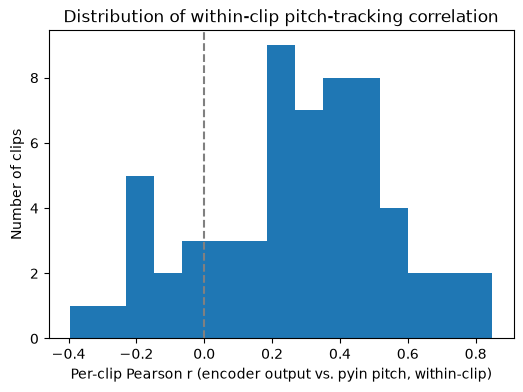

In [8]:
# NOT explicitly requested — adding this because the pooled correlation
# above has a real methodological gap given how this encoder was trained.
#
# The shift-matching puzzle only trains
# encoder(shifted) - encoder(original) ≈ shift_semitones. It never anchors
# the encoder's ABSOLUTE output value for any given clip. So two different
# clips at genuinely different pitches could land at very different
# arbitrary baseline offsets, even if the encoder tracks relative pitch
# changes perfectly WITHIN each clip. Pooling all 60 clips' frames together
# (Cell 7) conflates "does output track pitch within a clip" with "are
# baseline offsets comparable across clips" — only the first is actually
# guaranteed by this training objective.
#
# This computes a separate correlation per clip (its own frames only),
# sidestepping the cross-clip-offset issue. The median of these is arguably
# a more honest read of "did the encoder learn a real pitch signal."

per_clip_correlations = []
for (pair_idx, role), group in comparison_df.groupby(["pair_idx", "role"]):
    if len(group) < 5:  # too few voiced frames in this clip to trust a correlation
        continue
    r = group["encoder_output"].corr(group["f0_semitones"], method="pearson")
    per_clip_correlations.append(r)

per_clip_correlations = [r for r in per_clip_correlations if pd.notna(r)]
per_clip_correlations = np.array(per_clip_correlations)

print(
    f"Per-clip Pearson r: median={np.median(per_clip_correlations):.3f}, "
    f"mean={np.mean(per_clip_correlations):.3f}, "
    f"n_clips={len(per_clip_correlations)} (of up to 60)"
)

plt.figure(figsize=(6, 4))
plt.hist(per_clip_correlations, bins=15)
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Per-clip Pearson r (encoder output vs. pyin pitch, within-clip)")
plt.ylabel("Number of clips")
plt.title("Distribution of within-clip pitch-tracking correlation")
plt.show()

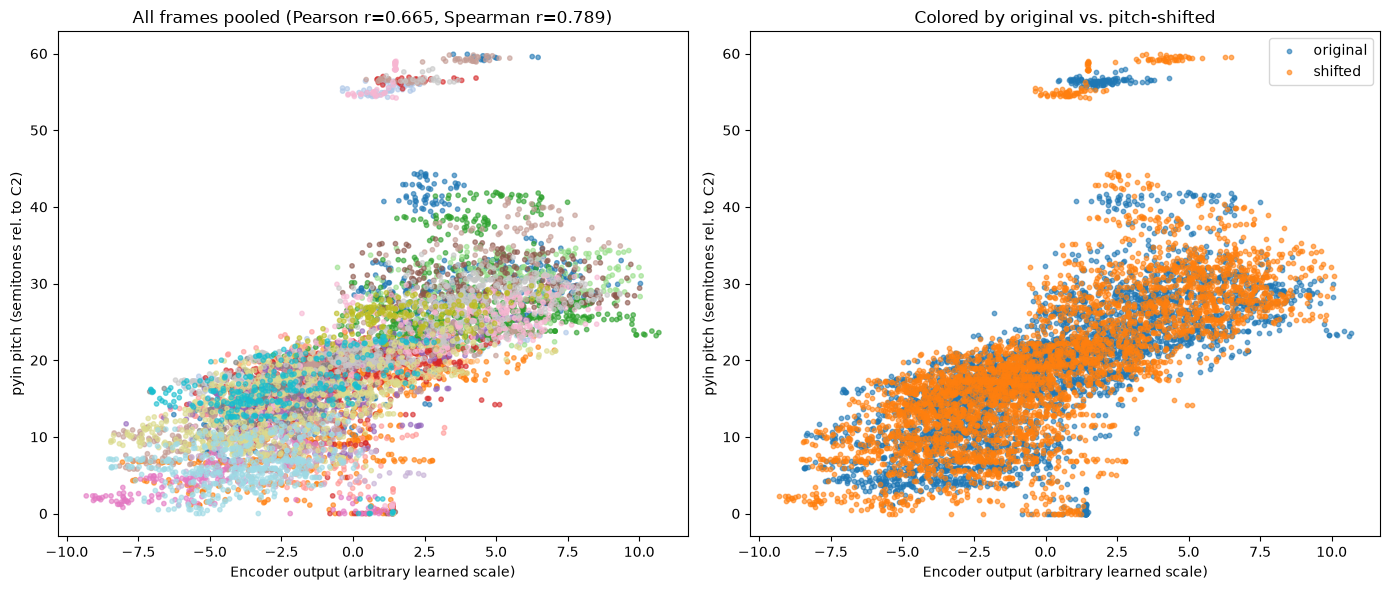

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: all frames pooled, colored by clip (pair_idx) — if per-clip offset
# drift (Cell 8's concern) is real, you'll see it here as separate colored
# streaks rather than one continuous trend.
axes[0].scatter(
    comparison_df["encoder_output"],
    comparison_df["f0_semitones"],
    c=comparison_df["pair_idx"],
    cmap="tab20",
    s=10,
    alpha=0.6,
)
axes[0].set_xlabel("Encoder output (arbitrary learned scale)")
axes[0].set_ylabel("pyin pitch (semitones rel. to C2)")
axes[0].set_title(f"All frames pooled (Pearson r={pearson_r:.3f}, Spearman r={spearman_r:.3f})")

# Right: same data, colored by original vs. pitch-shifted instead
for role, group in comparison_df.groupby("role"):
    axes[1].scatter(group["encoder_output"], group["f0_semitones"], s=10, alpha=0.6, label=role)
axes[1].set_xlabel("Encoder output (arbitrary learned scale)")
axes[1].set_ylabel("pyin pitch (semitones rel. to C2)")
axes[1].set_title("Colored by original vs. pitch-shifted")
axes[1].legend()

plt.tight_layout()
plt.show()

## Interpretation

**Pooled correlation:** Pearson r = _____, Spearman r = _____

**Per-clip correlation:** median r = _____, mean r = _____

**What to look for:**
- A pooled r close to 0 but a per-clip median r clearly above 0 would mean
  the encoder DID learn to track pitch within a clip, but with arbitrary,
  incomparable offsets across clips — expected given the training
  objective, and arguably a success, not a failure.
- A per-clip median r also close to 0 would mean the noisy loss really did
  fail to produce a usable pitch signal, not just a noisy-but-working one.
- Check the left scatter plot in Cell 9 for visible per-clip color
  clustering — that's the visual signature of the offset issue Cell 8
  investigates numerically.

_(Fill in after running — not fabricating a conclusion here.)_